In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler

C:\Users\admin\AppData\Local\Temp\ipykernel_20212\3847547620.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='pick_frequency', y='stock_code', data=top_fast_skus, palette='Blues_r')


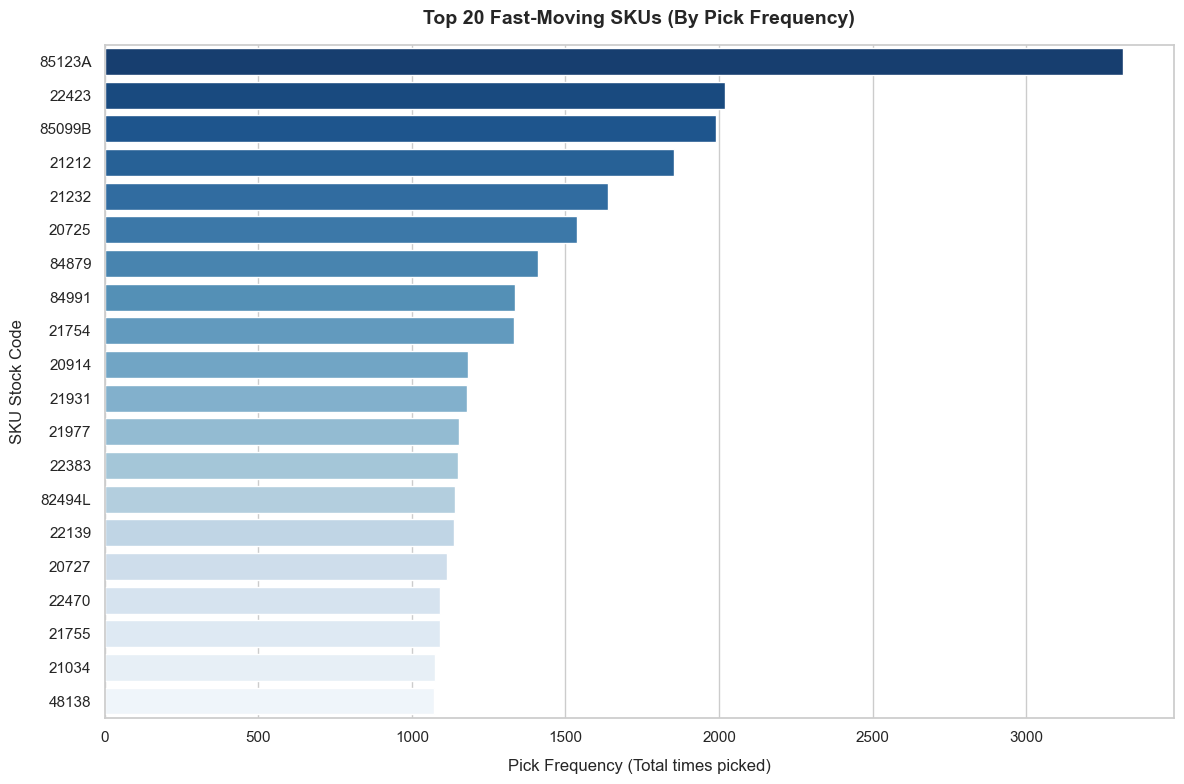

In [17]:
# =====================================================================
# TOP 20 FAST-MOVING SKUs (BASED ON PICK FREQUENCY)
# =====================================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load feature data (This file is already aggregated, 1 row per SKU)
# Note: Ensure the filename is sku_features.csv (with an 's')
df = pd.read_csv('../features/sku_features.csv')

# 2. Sort data directly (No groupby operation needed)
# Sort descending by 'pick_frequency' (or 'total_sales' if preferred) and get top 20
top_fast_skus = df.sort_values(by='pick_frequency', ascending=False).head(20)

# 3. Configure plot style and size
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

# 4. Plot horizontal bar chart
# Set x-axis to 'pick_frequency' to match the sorted data
sns.barplot(x='pick_frequency', y='stock_code', data=top_fast_skus, palette='Blues_r')

# 5. Set chart title and axis labels
plt.title('Top 20 Fast-Moving SKUs (By Pick Frequency)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Pick Frequency (Total times picked)', fontsize=12, labelpad=10)
plt.ylabel('SKU Stock Code', fontsize=12, labelpad=10)

# 6. Adjust layout and display plot
plt.tight_layout()
plt.show()

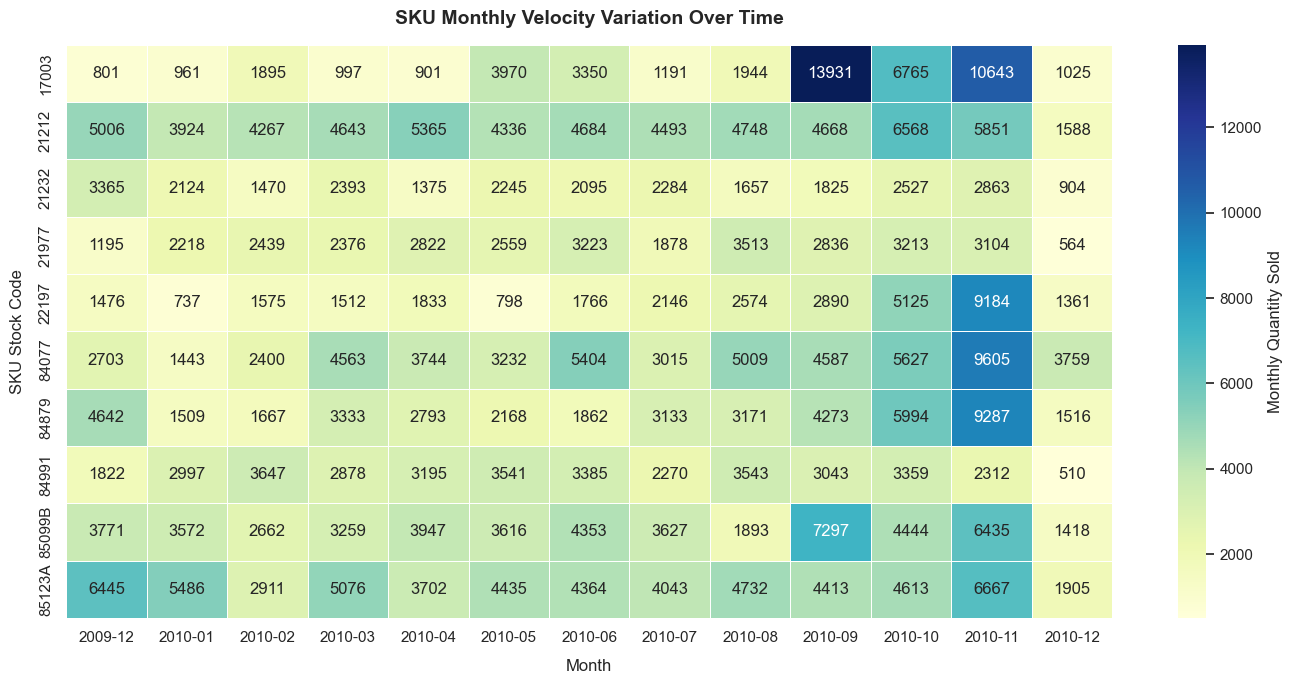

In [18]:
# Purchase frequency fluctuation of description groups over time.

# Load monthly feature data
df = pd.read_csv('../features/sku_monthly_features.csv')
# Combine year and month into a single YYYY-MM string column
df['month'] = df['order_year'].astype(str) + '-' + df['order_month'].astype(str).str.zfill(2)

# Get the top 10 fast-moving SKUs based on total quantity to keep the plot clean
top_skus = df.groupby('stock_code')['monthly_quantity'].sum().sort_values(ascending=False).head(10).index
df_top = df[df['stock_code'].isin(top_skus)]

# Pivot data into a matrix format (SKUs as rows, Months as columns)
heatmap_data = df_top.pivot(index='stock_code', columns='month', values='monthly_quantity')

# Fill missing months with 0 if a product had no sales in that period
heatmap_data = heatmap_data.fillna(0)

# Configure plot style and size
plt.figure(figsize=(14, 7))
sns.set_theme(style="white")

# Plot heatmap to visualize velocity trends over time
sns.heatmap(heatmap_data, cmap='YlGnBu', annot=True, fmt='.0f', linewidths=0.5, cbar_kws={'label': 'Monthly Quantity Sold'})

# Set chart title and axis labels
plt.title('SKU Monthly Velocity Variation Over Time', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Month', fontsize=12, labelpad=10)
plt.ylabel('SKU Stock Code', fontsize=12, labelpad=10)

# Adjust layout and display plot
plt.tight_layout()
plt.show()

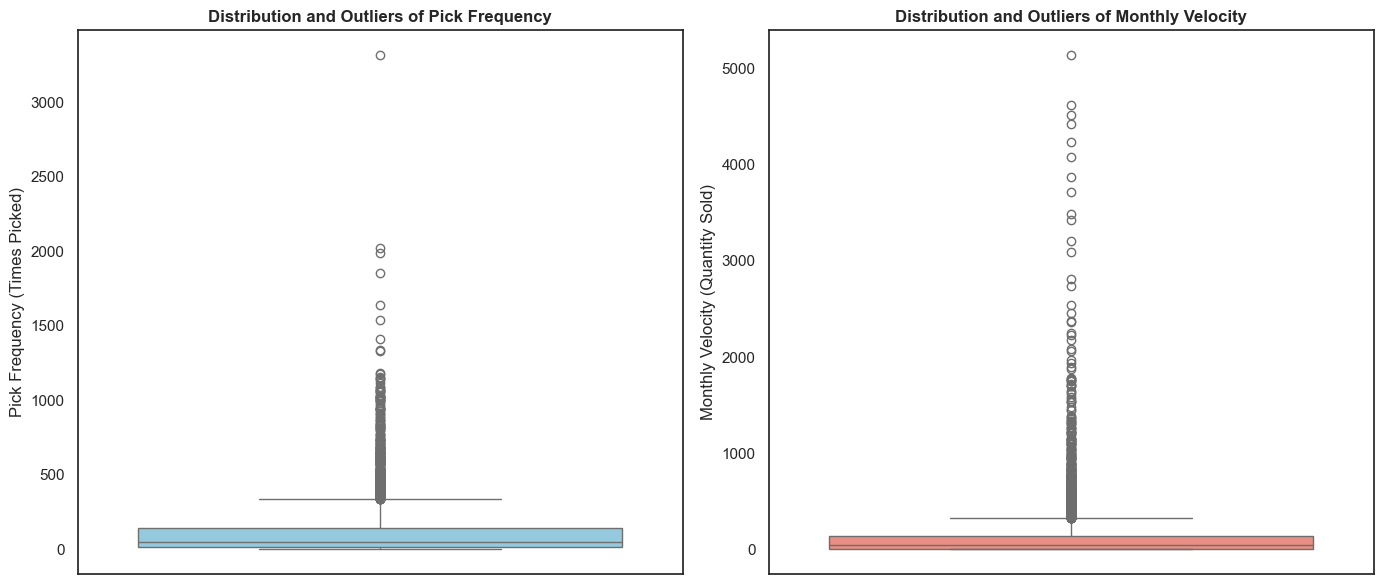

In [19]:

# Đọc file dữ liệu SKU
df_sku = pd.read_csv('../features/sku_features.csv')

# Tạo khung vẽ 2 biểu đồ
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.set_theme(style="whitegrid")

# Biểu đồ 1: Tần suất nhặt hàng (Pick Frequency)
sns.boxplot(data=df_sku, y='pick_frequency', ax=axes[0], color='skyblue')
axes[0].set_title('Distribution and Outliers of Pick Frequency', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Pick Frequency (Times Picked)')

# Biểu đồ 2: Tốc độ bán hàng (Monthly Velocity)
sns.boxplot(data=df_sku, y='monthly_velocity', ax=axes[1], color='salmon')
axes[1].set_title('Distribution and Outliers of Monthly Velocity', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Monthly Velocity (Quantity Sold)')

plt.tight_layout()
plt.show()

In [12]:
import pandas as pd

def calculate_data_distribution(df, column_name):
    # Calculate Q1 (25th percentile) and Q3 (75th percentile)
    Q1 = df[column_name].quantile(0.25)
    Q3 = df[column_name].quantile(0.75)
    
    # Calculate IQR (Interquartile Range)
    IQR = Q3 - Q1
    
    # Calculate lower and upper bounds (1.5 * IQR rule for Boxplots)
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Count Outliers
    outliers_count = len(df[(df[column_name] < lower_bound) | (df[column_name] > upper_bound)])
    
    # Count Inliers
    inliers_count = len(df) - outliers_count
    
    total_count = len(df)
    outlier_percentage = (outliers_count / total_count) * 100
    inlier_percentage = (inliers_count / total_count) * 100
    
    print(f"--- DISTRIBUTION STATISTICS FOR COLUMN '{column_name.upper()}' ---")
    print(f"Normal Range (Mathematical): From {lower_bound:.2f} to {upper_bound:.2f}")
    print(f"✅ Inliers count : {inliers_count:,.0f} rows | Percentage: {inlier_percentage:.2f}%")
    print(f"🚨 Outliers count: {outliers_count:,.0f} rows | Percentage: {outlier_percentage:.2f}%\n")

# Run distribution check for your monthly SKU data
calculate_data_distribution(df_sku, 'monthly_velocity')
calculate_data_distribution(df_sku, 'pick_frequency')

--- DISTRIBUTION STATISTICS FOR COLUMN 'MONTHLY_VELOCITY' ---
Normal Range (Mathematical): From -181.15 to 323.67
✅ Inliers count : 3,661 rows | Percentage: 88.64%
🚨 Outliers count: 469 rows | Percentage: 11.36%

--- DISTRIBUTION STATISTICS FOR COLUMN 'PICK_FREQUENCY' ---
Normal Range (Mathematical): From -178.50 to 337.50
✅ Inliers count : 3,748 rows | Percentage: 90.75%
🚨 Outliers count: 382 rows | Percentage: 9.25%



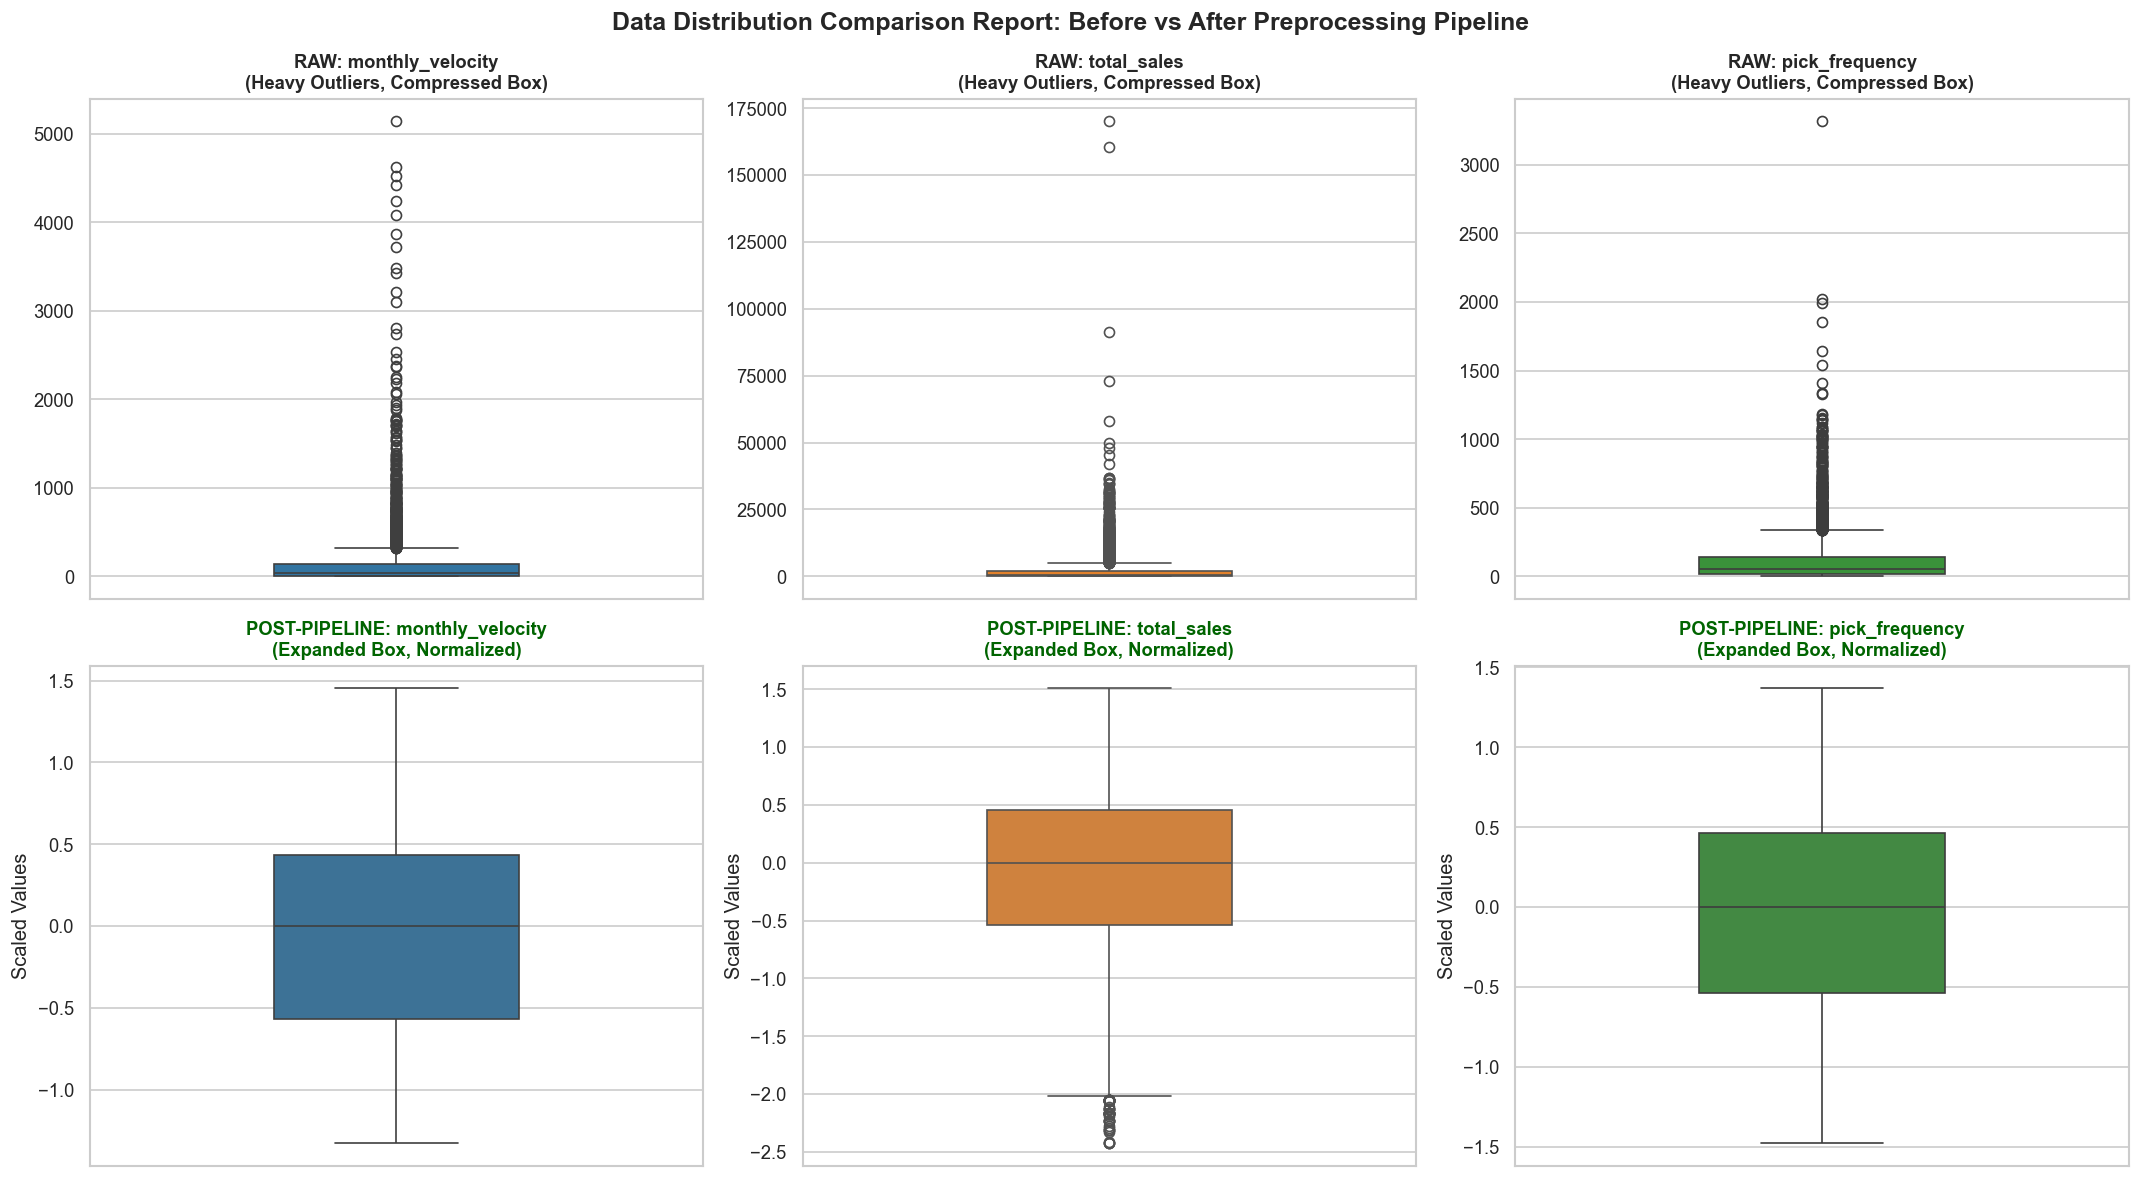

In [20]:
# =====================================================================
# DATA DISTRIBUTION COMPARISON: BEFORE VS AFTER PIPELINE
# =====================================================================


# 1. Pipeline function to generate scaled data for plotting
def optimize_preprocessing_pipeline(data, feature_cols, lower_q=0.0, upper_q=0.995):
    df_out = data[feature_cols].copy()
    for col in feature_cols:
        u_limit = df_out[col].quantile(upper_q)
        df_out[col] = np.where(df_out[col] > u_limit, u_limit, df_out[col])
        df_out[col] = np.log1p(df_out[col])
        
    scaler = RobustScaler()
    scaled_data = scaler.fit_transform(df_out)
    df_scaled = pd.DataFrame(scaled_data, columns=feature_cols, index=data.index)
    return df_scaled

# 2. Load raw data and extract features
df_raw = pd.read_csv('../features/sku_features.csv')
features = ['monthly_velocity', 'total_sales', 'pick_frequency']

# 3. Generate scaled data dynamically
df_scaled = optimize_preprocessing_pipeline(df_raw, features)

# 4. Initialize smart plot grid: 2 rows x 3 columns
fig, axes = plt.subplots(2, 3, figsize=(18, 10), dpi=120)
sns.set_theme(style="whitegrid")

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for i, col in enumerate(features):
    # --- ROW 1: ORIGINAL RAW STATE ---
    sns.boxplot(data=df_raw, y=col, ax=axes[0, i], color=colors[i], width=0.4)
    axes[0, i].set_title(f'RAW: {col}\n(Heavy Outliers, Compressed Box)', fontsize=11, fontweight='bold')
    axes[0, i].set_ylabel('')
    
    # --- ROW 2: POST-PIPELINE STATE ---
    sns.boxplot(data=df_scaled, y=col, ax=axes[1, i], color=colors[i], width=0.4, saturation=0.6)
    axes[1, i].set_title(f'POST-PIPELINE: {col}\n(Expanded Box, Normalized)', fontsize=11, fontweight='bold', color='darkgreen')
    axes[1, i].set_ylabel('Scaled Values')

# 5. Add global title and display
plt.suptitle('Data Distribution Comparison Report: Before vs After Preprocessing Pipeline', fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

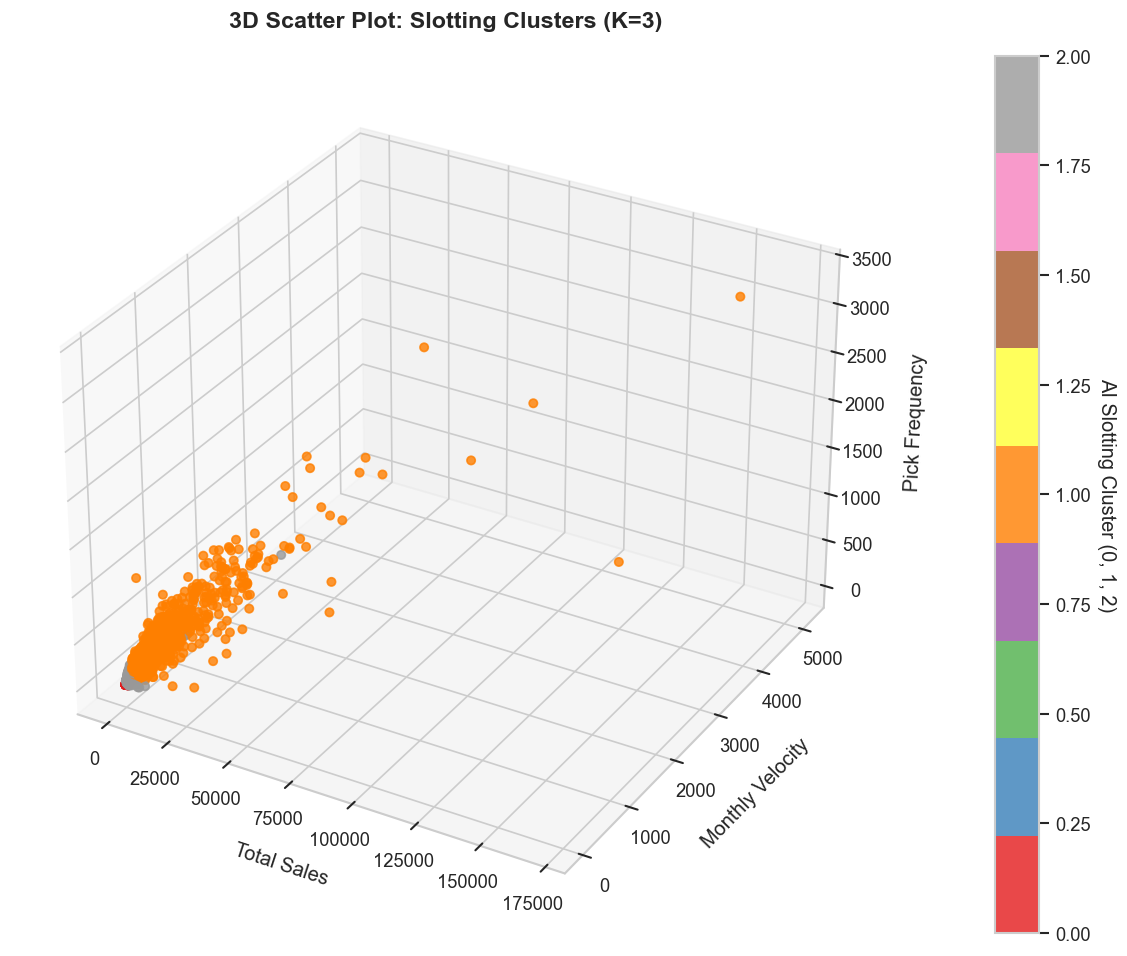

In [ ]:
# =====================================================================
# 4. 3D SCATTER PLOT: K-MEANS CLUSTERING RESULTS (LOG-SCALED FOR VISIBILITY)
# =====================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the finalized clustered data
df_final = pd.read_csv('../features/sku_clusters_final.csv')

# 2. Initialize 3D plot space
fig = plt.figure(figsize=(10, 8), dpi=120)
ax = fig.add_subplot(111, projection='3d')

# 3. Apply Log1p transformation EXCLUSIVELY for plotting 
# This prevents the extreme outliers from squishing the visualization
x = np.log1p(df_final['total_sales'])
y = np.log1p(df_final['monthly_velocity'])
z = np.log1p(df_final['pick_frequency'])

# 4. Plot the data
scatter = ax.scatter(x, y, z, 
                     c=df_final['Cluster'],    # Color points based on AI cluster
                     cmap='Set1',              # Distinct colors for each cluster
                     s=25,                     # Point size
                     alpha=0.8)                # Slight transparency

# 5. Add titles and labels to axes
ax.set_title('3D Scatter Plot: Slotting Clusters (Log-Scaled)', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Log (Total Sales)', labelpad=10)
ax.set_ylabel('Log (Monthly Velocity)', labelpad=10)
ax.set_zlabel('Log (Pick Frequency)', labelpad=10)

# 6. Add color bar legend
cbar = plt.colorbar(scatter, pad=0.1)
cbar.set_label('AI Slotting Cluster (0, 1, 2)', rotation=270, labelpad=15)

# 7. Adjust layout and display
plt.tight_layout()
plt.show()